1. import & config

In [ ]:
!pip install openai

  Using cached openai-1.86.0-py3-none-any.whl.metadata (25 kB)
  Using cached anyio-4.9.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jiter-0.10.0-cp312-cp312-win_amd64.whl.metadata (5.3 kB)
     ---------------------------------------- 0.0/68.0 kB ? eta -:--:--
     ---------------------------------------- 68.0/68.0 kB 1.9 MB/s eta 0:00:00
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.33.2-cp312-cp312-win_amd64.whl.metadata (6.9 kB)
  Using cached typing_inspection-0.4.1-py3-none-any.whl.metadata (2.6 kB)
Using cached openai-1.86.0-py3-none-any.whl (730 kB)
Using cached anyio-4.9.0-py3-none-any.whl (100 kB)
Using c


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Cell 1: Imports, Configuration, and API Key Verification
import openai
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import time
import re

# Configuration
openai.api_key = ""
VALID_STANCES = ['support', 'support_exemption', 'against', 'against_exemption', 'uncertain']

# API Key Verification
def verify_openai_api_key():
    try:
        # Make a minimal API call to check key validity
        openai.models.list()
        print("OpenAI API key is valid.")
    except Exception as e:
        print("OpenAI API key is invalid or there is a connection issue.")
        print(f"Error details: {e}")
        raise RuntimeError("OpenAI API key verification failed. Please check your API key and network connection.")

# Run verification at the top of the notebook
verify_openai_api_key()

OpenAI API key is valid.


2. prompt eng

In [ ]:
def generate_prompt(comment):
    return f"""
Classify the following company comment about PFAS regulations in two steps:

Step 1: Is the main stance "support", "against", or "uncertain"?
- "support": Explicitly endorses the PFAS ban or restriction and provides supporting evidence.
- "against": Strongly argues against the PFAS ban, citing economic impacts or lack of alternatives.
- "uncertain": Provides neutral factual information without clear stance.

Step 2: If the stance is "support" or "against", does the comment request a specific exemption or transitional period? If so, append "_exemption" to the stance (e.g., "support_exemption" or "against_exemption").

Respond with only the final classification (support, support_exemption, against, against_exemption, or uncertain) and a confidence score from 0.0 to 1.0 in this format:
Classification: [category]
Confidence: [score]

Comment:
\"\"\"{comment}\"\"\"
"""

3. gpt classification core

In [ ]:
VALID_STANCES = [
    'support', 'support_exemption',
    'against', 'against_exemption',
    'uncertain'
]

def parse_gpt_response(result_text):
    stance_match = re.search(r'Classification:\s*([a-zA-Z_]+)', result_text, re.IGNORECASE)
    confidence_match = re.search(r'Confidence:\s*([\d.]+)', result_text, re.IGNORECASE)

    stance = stance_match.group(1).lower() if stance_match else 'uncertain'
    confidence = float(confidence_match.group(1)) if confidence_match else 0.5

    if stance not in VALID_STANCES:
        stance = 'uncertain'
        confidence = 0.3

    return stance, confidence

def classify_with_gpt(comment, max_retries=3):
    prompt = generate_prompt(comment)

    for attempt in range(max_retries):
        try:
            response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=100,
                temperature=0
            )

            result_text = response.choices[0].message.content.strip()
            stance, confidence = parse_gpt_response(result_text)

            return {
                'stance': stance,
                'confidence_score': confidence,
                'raw_response': result_text
            }

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                return {
                    'stance': 'uncertain',
                    'confidence_score': 0.0,
                    'raw_response': f"Error: {str(e)}"
                }

4. data processing

In [ ]:
def apply_gpt_classification_to_dataframe(df, text_column='combined_text', batch_size=5):
    """Apply GPT classification to dataframe with rate limiting"""
    results = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch = df.iloc[i:i+batch_size]
        batch_results = []

        for text in batch[text_column]:
            result = classify_with_gpt(text)
            batch_results.append(result)
            time.sleep(1)  # Rate limiting

        results.extend(batch_results)

    df_classified = df.copy()
    df_classified['stance'] = [r['stance'] for r in results]
    df_classified['confidence_score'] = [r['confidence_score'] for r in results]
    df_classified['gpt_raw_response'] = [r['raw_response'] for r in results]

    return df_classified

5. validation and analysis

In [ ]:
def perform_gpt_validation_checks(df, text_column='combined_text'):
    """Perform validation checks on GPT classification results"""

    # 1. Distribution of stances
    stance_distribution = df['stance'].value_counts()
    print("\nGPT Stance Distribution:")
    print(stance_distribution)

    # 2. Confidence score distribution
    print("\nGPT Confidence Score Statistics:")
    print(df['confidence_score'].describe())

    # 3. Check for potential misclassifications
    low_confidence = df[df['confidence_score'] < 0.4]
    print(f"\nNumber of low confidence GPT classifications: {len(low_confidence)}")

    # 4. Analyze text length vs confidence
    df['text_length'] = df[text_column].str.len()
    correlation = df['text_length'].corr(df['confidence_score'])
    print(f"\nCorrelation between text length and GPT confidence: {correlation:.3f}")

    return {
        'stance_distribution': stance_distribution,
        'confidence_stats': df['confidence_score'].describe(),
        'low_confidence_count': len(low_confidence),
        'text_length_correlation': correlation
    }

6. visualization

In [ ]:
def plot_stance_distribution(df):
    """Plot stance distribution bar chart"""
    plt.figure(figsize=(10, 6))
    stance_counts = df['stance'].value_counts()
    sns.barplot(x=stance_counts.index, y=stance_counts.values, palette='viridis')
    plt.title('GPT Stance Distribution')
    plt.xlabel('Stance')
    plt.ylabel('Number of Entries')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return stance_counts

def plot_stance_pie_chart(stance_counts):
    """Plot stance distribution pie chart"""
    plt.figure(figsize=(8, 8))
    plt.pie(stance_counts, labels=stance_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('viridis', len(stance_counts)))
    plt.title('GPT Stance Distribution')
    plt.show()

def plot_confidence_boxplot(df):
    """Plot confidence score box plot by stance"""
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='stance', y='confidence_score', data=df)
    plt.title('GPT Confidence Score Distribution by Stance')
    plt.xlabel('Stance')
    plt.ylabel('Confidence Score')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_confidence_histogram(df):
    """Plot confidence score histogram"""
    plt.figure(figsize=(10, 6))
    plt.hist(df['confidence_score'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('GPT Confidence Score Distribution')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

7. results summary and export

In [ ]:
def generate_results_summary(df):
    """Generate summary statistics for classification results"""
    confident_count = len(df[df['stance'] != 'uncertain'])
    uncertain_count = len(df[df['stance'] == 'uncertain'])
    stance_counts = df['stance'].value_counts()

    summary = {
        'total_samples': len(df),
        'confident_count': confident_count,
        'uncertain_count': uncertain_count,
        'average_confidence': df['confidence_score'].mean(),
        'stance_breakdown': {
            stance: {
                'count': count,
                'percentage': count/len(df)*100,
                'avg_confidence': df[df['stance'] == stance]['confidence_score'].mean()
            }
            for stance, count in stance_counts.items()
        }
    }

    return summary

def save_results(df, output_filename):
    """Save classification results to CSV"""
    df.to_csv(output_filename, index=False, encoding='utf-8')
    print(f"Results saved to '{output_filename}'")

8. main

100%|██████████| 1002/1002 [1:56:46<00:00,  6.99s/it]


GPT Stance Distribution:
stance
support              1455
against_exemption    1097
uncertain            1036
against               998
support_exemption     423
Name: count, dtype: int64

GPT Confidence Score Statistics:
count    5009.000000
mean        0.938341
std         0.058150
min         0.500000
25%         0.900000
50%         0.950000
75%         1.000000
max         1.000000
Name: confidence_score, dtype: float64

Number of low confidence GPT classifications: 0

Correlation between text length and GPT confidence: 0.414



C:\Users\hclu1\AppData\Local\Temp\ipykernel_5800\1318126125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stance_counts.index, y=stance_counts.values, palette='viridis')


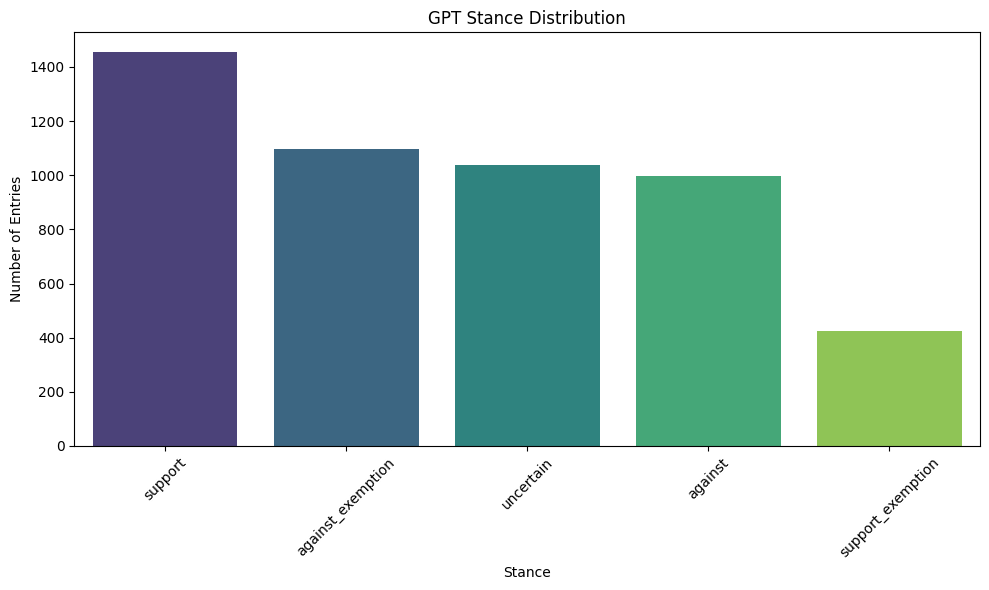

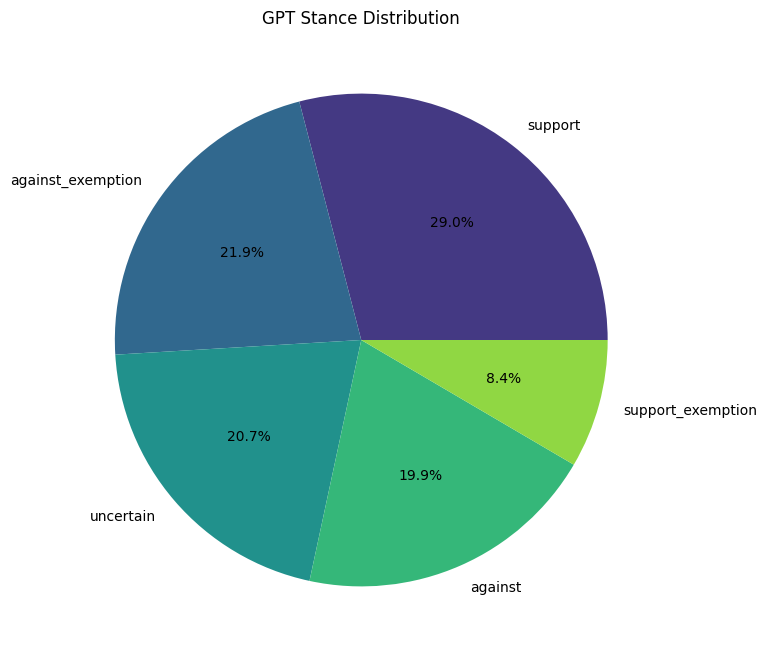

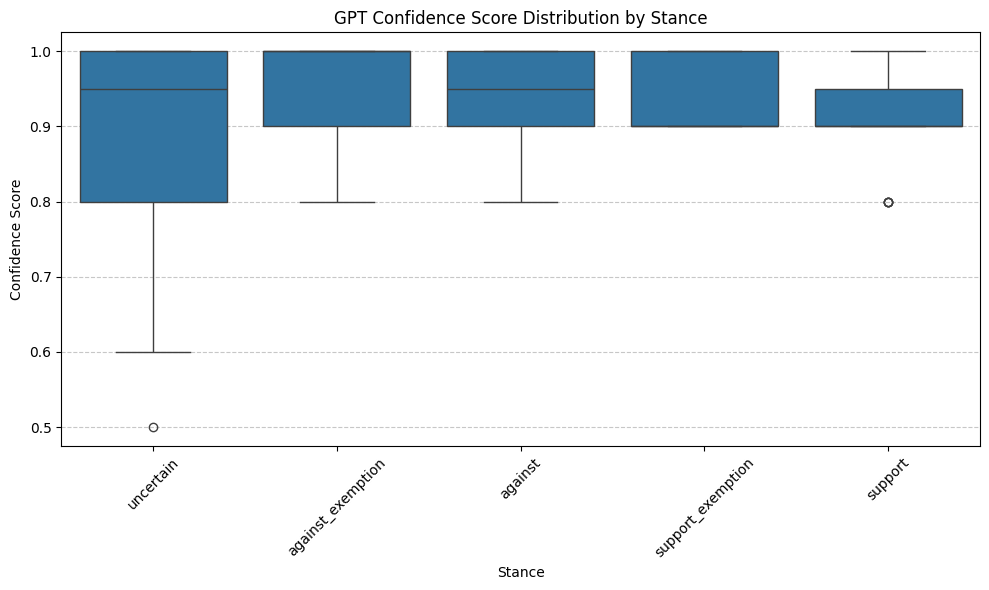

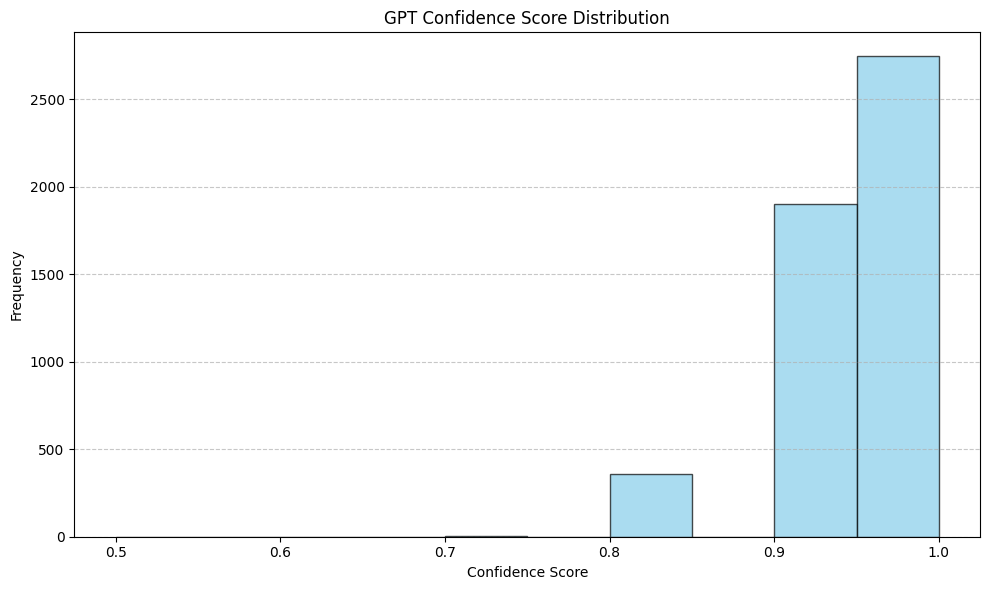

Results saved to 'df_translated_full_gpt_sentiment.csv'

Classification Summary:
Total samples: 5009
Confident classifications: 3973
Uncertain classifications: 1036
Average confidence: 0.938


In [ ]:
# Cell 8: Main Execution
def run_gpt_classification_full(df):
    """Main execution function for the full dataset"""
    # Apply classification to the full dataset
    df_classified = apply_gpt_classification_to_dataframe(df)

    # Perform validation
    validation_results = perform_gpt_validation_checks(df_classified)

    # Generate visualizations
    stance_counts = plot_stance_distribution(df_classified)
    plot_stance_pie_chart(stance_counts)
    plot_confidence_boxplot(df_classified)
    plot_confidence_histogram(df_classified)

    # Generate and display summary
    summary = generate_results_summary(df_classified)

    # Save results
    save_results(df_classified, 'df_translated_full_gpt_sentiment.csv')

    return df_classified, summary

if __name__ == "__main__":
    # Load data
    df_translated = pd.read_csv('df_translated.csv')

    # Run classification on the full dataset
    df_results, summary = run_gpt_classification_full(df_translated)

    # Display summary
    print("\nClassification Summary:")
    print(f"Total samples: {summary['total_samples']}")
    print(f"Confident classifications: {summary['confident_count']}")
    print(f"Uncertain classifications: {summary['uncertain_count']}")
    print(f"Average confidence: {summary['average_confidence']:.3f}")

cost estimator

In [ ]:
def estimate_gpt35_cost_from_text(df, text_column='combined_text', prompt_template_tokens=100, response_tokens=20):
    # Calculate average number of characters in the comments
    avg_chars = df[text_column].str.len().mean()
    # Estimate tokens per comment (1 token ≈ 4 characters)
    avg_comment_tokens = avg_chars / 4
    tokens_per_row = prompt_template_tokens + avg_comment_tokens + response_tokens
    n_rows = len(df)
    total_tokens = int(n_rows * tokens_per_row)
    cost_per_million = 1.0  # $1 per 1M tokens (input+output, blended)
    estimated_cost = (total_tokens / 1_000_000) * cost_per_million
    print(f"Rows: {n_rows}")
    print(f"Average characters per comment: {avg_chars:.1f}")
    print(f"Estimated tokens per comment: {avg_comment_tokens:.1f}")
    print(f"Estimated tokens per row (prompt+comment+response): {tokens_per_row:.1f}")
    print(f"Total tokens: {total_tokens:,}")
    print(f"Estimated cost: ${estimated_cost:.2f}")
    return total_tokens, estimated_cost

# Example usage:
estimate_gpt35_cost_from_text(df_translated)

Rows: 5009
Average characters per comment: 3465.2
Estimated tokens per comment: 866.3
Estimated tokens per row (prompt+comment+response): 986.3
Total tokens: 4,940,341
Estimated cost: $4.94


(4940341, 4.940341)